In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

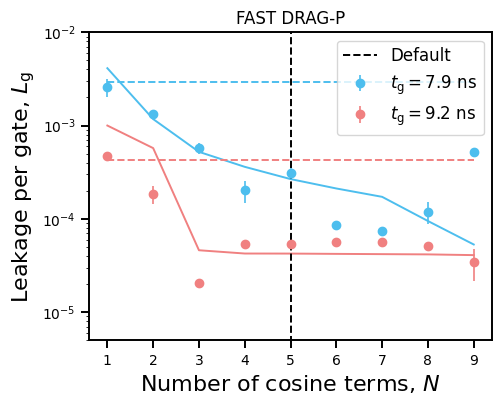

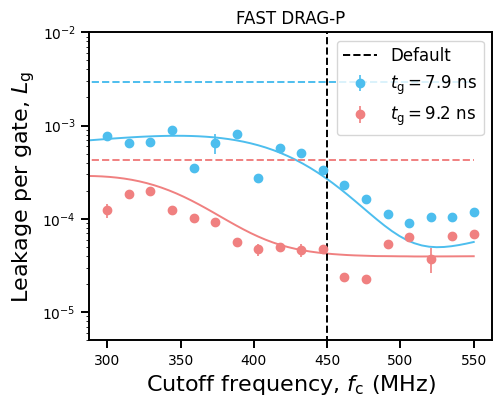

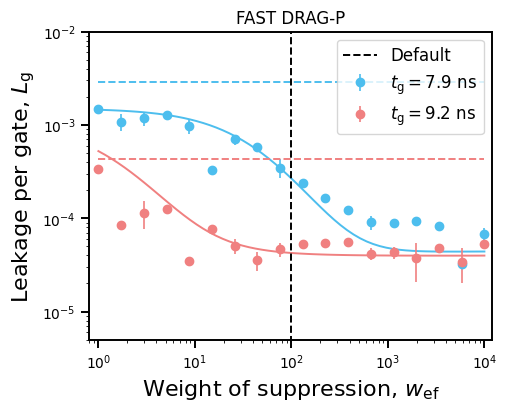

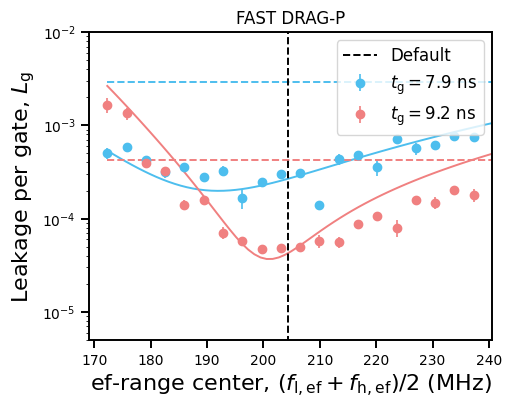

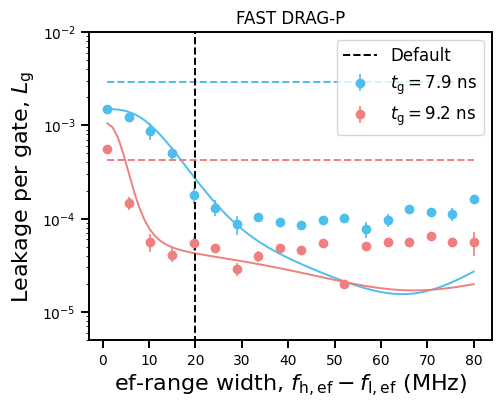

In [2]:
#Re-read csv-files and plot

sweep_parameter_list = ['number_of_cosine_terms', 'cutoff_frequency', 'ef-range_weight', 'ef-range_center_frequency', 'ef-range_width']
from_parameter_to_xlabel = {'number_of_cosine_terms': r'Number of cosine terms, $N$',
                            'cutoff_frequency': r'Cutoff frequency, $f_\mathrm{c}$ (MHz)',
                            'ef-range_weight': r'Weight of suppression, $w_\mathrm{ef}$',
                            'ef-range_center_frequency': r'ef-range center, $(f_{\mathrm{l}, \mathrm{ef}} + f_{\mathrm{h}, \mathrm{ef}}) / 2$ (MHz)',
                            'ef-range_width': r'ef-range width, $f_{\mathrm{h}, \mathrm{ef}} - f_{\mathrm{l}, \mathrm{ef}}$ (MHz)',
                           }
light_blue = [0.3010, 0.7450, 0.9330]
light_red = [240/255,128/255,128/255]
colors_list = [light_blue, light_red]

for sweep_parameter in sweep_parameter_list: 
    fig, ax = plt.subplots(1, 1, figsize=(5.2,4))
    for idx_duration in range(2):
        folder_path = os.path.join(sweep_parameter, 'FAST_DRAG-P_idx_of_duration_%d'%(idx_duration))
        # Experiment
        leakage_error_exp_arr = np.genfromtxt(os.path.join(folder_path, 'leakage_error_exp_arr.csv'), delimiter=',')
        leakage_error_exp_uncertainty_arr = np.genfromtxt(os.path.join(folder_path, 'leakage_error_exp_uncertainty_arr.csv'), delimiter=',')
        sweep_parameter_exp_arr = np.genfromtxt(os.path.join(folder_path, 'sweep_parameter_exp_arr.csv'), delimiter=',')
        leakage_error_sim_arr = np.genfromtxt(os.path.join(folder_path, 'leakage_error_sim_arr.csv'), delimiter=',')
        sweep_parameter_sim_arr = np.genfromtxt(os.path.join(folder_path, 'sweep_parameter_sim_arr.csv'), delimiter=',')
        default_parameter_value = np.genfromtxt(os.path.join(folder_path, 'default_parameter_value.csv'), delimiter=',')
        leakage_error_cosine_DRAG_P = np.genfromtxt(os.path.join(folder_path, 'leakage_error_cosine_DRAG.csv'), delimiter=',')
        gate_duration = np.genfromtxt(os.path.join(folder_path, 'gate_duration.csv'), delimiter=',')
        if sweep_parameter in ['cutoff_frequency', 'ef-range_center_frequency', 'ef-range_width']:
            # from Hz to MHz
            sweep_parameter_exp_arr = sweep_parameter_exp_arr /1e6
            sweep_parameter_sim_arr = sweep_parameter_sim_arr /1e6
            default_parameter_value = default_parameter_value /1e6
        plt.errorbar(sweep_parameter_exp_arr, leakage_error_exp_arr, yerr=leakage_error_exp_uncertainty_arr, fmt='o', linewidth=1.2, color=colors_list[idx_duration], label = r'$t_\mathrm{g} = %.1f$ ns'%(float(gate_duration)*1e9))
        plt.plot(sweep_parameter_sim_arr, leakage_error_sim_arr,  '-', color=colors_list[idx_duration], linewidth=1.4)
        plt.plot(sweep_parameter_sim_arr, [leakage_error_cosine_DRAG_P] * len(sweep_parameter_sim_arr),  '--', 
                     color=colors_list[idx_duration], linewidth=1.4) 
    plt.plot([float(default_parameter_value), float(default_parameter_value)] , [1e-6, 1e-2],  '--',  color='k', linewidth=1.4, label='Default')
    plt.xlabel(from_parameter_to_xlabel[sweep_parameter], fontsize = 16)
    #plt.ylabel(r'Gate error ($\times 10^{-4}$)', fontsize = 16)
    plt.ylabel(r'Leakage per gate, $L_\mathrm{g}$', fontsize = 16)
    plt.legend(fontsize = 12, loc = 'upper right') #'upper right')
    plt.ylim([5e-6, 1e-2])
    xmax = np.max(sweep_parameter_exp_arr)
    xmin = np.min(sweep_parameter_exp_arr)
    xmin_lim = xmin - (xmax - xmin) * 0.05
    xmax_lim = xmax + (xmax - xmin) * 0.05
    if sweep_parameter == 'ef-range_weight':
        xmin_lim = 0.8 * xmin
        xmax_lim = 1.2 * xmax
    plt.xlim([xmin_lim, xmax_lim])
    plt.title('FAST DRAG-P')

    ax.tick_params(length=6, width = 1.4)
    for side in ['top', 'left', 'right', 'bottom']:
        ax.spines[side].set_linewidth(1.4)
    ax.set_yscale("log")
    if sweep_parameter == 'ef-range_weight':
        ax.set_xscale("log")


In [9]:
gate_duration

array(7.91666667e-09)